# 24BAD099 - Rithish A

   user_id  movie_id  rating   timestamp
0       52        12       2  1000000028
1       93        26       1  1000000061
2       15        16       4  1000000092
3       72        37       3  1000000061
4       61        22       2  1000000056
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   user_id    500 non-null    int32
 1   movie_id   500 non-null    int32
 2   rating     500 non-null    int32
 3   timestamp  500 non-null    int32
dtypes: int32(4)
memory usage: 7.9 KB
None
user_id
94    0.507972
77    0.383482
12    0.366234
35    0.348337
60    0.342864
Name: 1, dtype: float64
Recommendations: [(43, np.float64(1.3819848419917742)), (19, np.float64(0.9395958449879692)), (10, np.float64(0.7149441186787195)), (12, np.float64(0.7149441186787195)), (48, np.float64(0.7149441186787195))]
RMSE: 2.151796474699299
MAE: 1.8755837187725268


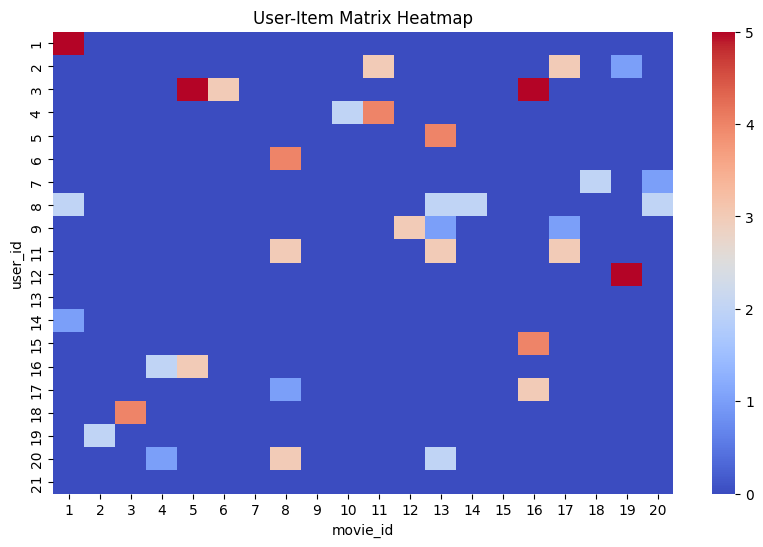

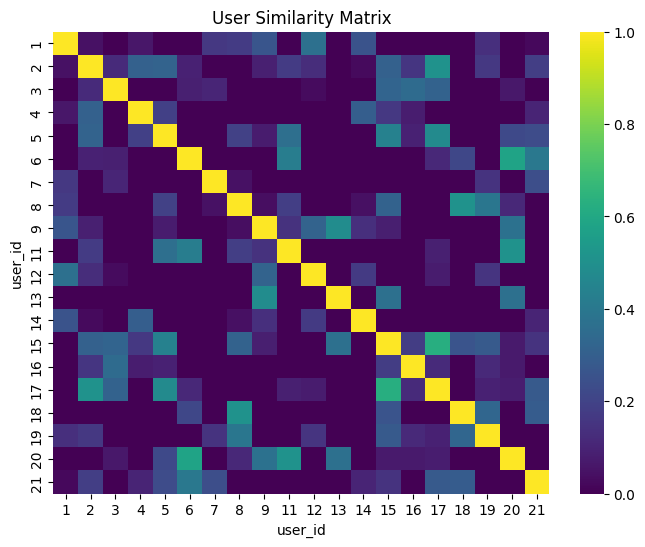

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

np.random.seed(42)
n_users = 100
n_movies = 50
n_ratings = 500

user_ids = np.random.randint(1, n_users + 1, n_ratings)
movie_ids = np.random.randint(1, n_movies + 1, n_ratings)
ratings = np.random.randint(1, 6, n_ratings)
timestamps = np.random.randint(1000000000, 1000000100, n_ratings)

data = pd.DataFrame({
    "user_id": user_ids,
    "movie_id": movie_ids,
    "rating": ratings,
    "timestamp": timestamps
})

print(data.head())
print(data.info())

user_item_matrix = data.pivot_table(index="user_id",
                                    columns="movie_id",
                                    values="rating",
                                    aggfunc='mean')

user_item_matrix_filled = user_item_matrix.fillna(0)

user_similarity = cosine_similarity(user_item_matrix_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.index)

def get_similar_users(user_id, n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    return similar_users.iloc[1:n+1]

print(get_similar_users(1))

def predict_rating(user_id, movie_id):
    similar_users = get_similar_users(user_id, n=5)
    ratings = user_item_matrix.loc[similar_users.index, movie_id]
    
    weighted_sum = np.dot(similar_users, ratings.fillna(0))
    sim_sum = similar_users.sum()
    
    if sim_sum == 0:
        return 0
    return weighted_sum / sim_sum

def recommend_movies(user_id, n=5):
    user_ratings = user_item_matrix.loc[user_id]
    unseen_movies = user_ratings[user_ratings.isna()].index
    
    predictions = {}
    for movie in unseen_movies:
        predictions[movie] = predict_rating(user_id, movie)
    
    recommended = sorted(predictions.items(),
                         key=lambda x: x[1],
                         reverse=True)[:n]
    
    return recommended

print("Recommendations:", recommend_movies(1))

actual = []
predicted = []

for user in user_item_matrix.index[:50]:  
    for movie in user_item_matrix.columns[:50]:
        if not np.isnan(user_item_matrix.loc[user, movie]):
            actual.append(user_item_matrix.loc[user, movie])
            predicted.append(predict_rating(user, movie))

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix_filled.iloc[:20, :20], cmap="coolwarm")
plt.title("User-Item Matrix Heatmap")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap="viridis")
plt.title("User Similarity Matrix")
plt.show()
